In [1]:
from libraries import *
from logger import setup_logger
from CVAE_model import ScreenDataset, VAE, Encoder, Decoder, get_loss_fn, EmbeddingLayer
from Training import train_model_CVAE, train_model_multilab, evaluate_model_CVAE, evaluate_model_CVAE_multilab

import torch
from torch.utils.data import Dataset, DataLoader

import bisect
from itertools import accumulate
import argparse

import sys
import os
import logger
import torch.nn as nn
import torch
from torch import optim
import random

from sklearn.covariance import GraphicalLassoCV, ledoit_wolf

In [2]:
def getDistDistr(inMat):

    myDist_1Copy = np.array(inMat)
    il1 = np.tril_indices(myDist_1Copy.shape[0])
    myDist_1Copy[il1] = np.nan
    myDist_1Copy = pd.DataFrame(myDist_1Copy)
    myDist_1Copy.index=inMat.index
    myDist_1Copy.columns=inMat.columns

    myDistMelted = pd.melt(myDist_1Copy, id_vars=None, ignore_index=False)
    myDistMelted["secondGuide"] = myDistMelted.index
    myDistMelted.columns=["FirstGuide", "EuclidianDistance", "SecondGuide"]
    myDistMelted.index = range(0,myDistMelted.shape[0])
    myDistMelted = myDistMelted.loc[~myDistMelted["EuclidianDistance"].isnull(),:]
    
    
    myDistMelted['FirstGene'] = [x.split("_")[0] for x in myDistMelted['FirstGuide'] ]
    myDistMelted['SecondGene'] = [x.split("_")[0] for x in myDistMelted['SecondGuide'] ]
    myDistMelted = myDistMelted.loc[myDistMelted["FirstGuide"] != myDistMelted["SecondGuide"],:]
    myDistMelted["GuideType"] = "Different_gene"
    myDistMelted.loc[myDistMelted["FirstGene"] == myDistMelted["SecondGene"],"GuideType"] = "Same_gene"
    myDistMelted.loc[myDistMelted["FirstGene"] == "CONTROL","GuideType"] = "CONTROL"
    myDistMelted.loc[myDistMelted["SecondGene"] == "CONTROL","GuideType"] = "CONTROL"
    
    
    myDistMeltedSame = myDistMelted.loc[myDistMelted["GuideType"] == "Same_gene",: ]
    myDistMeltedControl = myDistMelted.loc[myDistMelted["GuideType"] == "CONTROL",: ]
    myDistMeltedDifferent = myDistMelted.loc[myDistMelted["GuideType"] == "Different_gene",: ]

    random.seed(10)
    all_comp= range(myDistMeltedDifferent.shape[0])

    training = random.sample(all_comp, 
                             round(myDistMeltedDifferent.shape[0]*0.01))

    myDistMeltedDifferent = myDistMeltedDifferent.iloc[training,:]
    myDistMeltedSelected = pd.concat([myDistMeltedDifferent, myDistMeltedSame, myDistMeltedControl])
    
    myDistMeltedSelected.index = range(0, myDistMeltedSelected.shape[0],1)
    
    return(myDistMeltedSelected)



In [3]:
n_inputs = 6685
n_cond_in= 2132
n_cond= 64
n_latents= 64
save_dir= '/home/eraslab1/Projects/PerturbMap/SRC/Outputs/'
model_dir= 'model_4'
datafile= "./outputs/anndata/adataDC2ForGuideFiltering_v2.h5ad"
batch_size= 1000
project_dir= "/home/eraslab1/Projects/E3Ligase/analysisSingle"


In [4]:
os.getcwd()
os.chdir(project_dir)

In [5]:
net = VAE(n_inputs=n_inputs,
          n_latents=n_latents,
          n_cond=n_cond,
          n_cond_in=n_cond_in)

In [6]:
net.load_state_dict(torch.load(os.path.join(save_dir,model_dir,"best.pth"))['state_dict'])

<All keys matched successfully>

In [7]:
dataset = ScreenDataset(datafile)
dataloader = DataLoader(dataset, 
                        batch_size=batch_size,
                        drop_last=False,
                        shuffle=False,
                        num_workers=50)

In [8]:
allGuides = dataset.get_targets()

In [9]:
all_cellembeddings = []
all_guideembeddings = []
allConditions = []

for sample in dataloader:
    with torch.no_grad():
        #input = sample['y'].cuda() if next(model.parameters()).is_cuda else sample['y']
        #condition = sample['X'].cuda() if next(model.parameters()).is_cuda else sample['X']
        input = sample['y']
        condition = sample['X']
        guideembeddings = net.get_embedding(condition)
        cellembeddings = net.inference(input, condition)
        
        all_cellembeddings.append(cellembeddings)
        all_guideembeddings.append(guideembeddings)
        allConditions.append(condition)


In [10]:
all_cellembeddings = torch.cat(all_cellembeddings, 0)
all_guideembeddings = torch.cat(all_guideembeddings, 0)
allConditions = torch.cat(allConditions, 0)

all_cellembeddings = pd.DataFrame(all_cellembeddings.numpy())
all_guideembeddings = pd.DataFrame(all_guideembeddings.numpy())
allConditions = pd.DataFrame(allConditions.numpy())
allConditions.columns = allGuides

In [ ]:
## Check whether all controls are 0
# deneme = pd.DataFrame(allConditions.sum(axis=0))
# deneme["gene"] = [x.split("_")[0] for x in deneme.index]
# deneme.loc[deneme.gene=='ONE',0].sum()
# deneme.loc[deneme.gene=='NO',0].sum()

In [11]:
k = allConditions.sum(axis=1)
controlCells = k[k==0].index

In [12]:
unique_guideembeddings = []
guideNames = []

for elem in allConditions.columns:
    x = all_guideembeddings.loc[allConditions[elem] == 1,].drop_duplicates()
    if x.shape[0] == 1:
        unique_guideembeddings.append(x)
        guideNames.append(elem)
        
unique_guideembeddings.append(all_guideembeddings.loc[controlCells,:].drop_duplicates())
guideNames.append("CONTROL")
unique_guideembeddings = pd.concat(unique_guideembeddings)
unique_guideembeddings.index = guideNames

In [13]:
unique_guideembeddings

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
4921501E09Rik_1,0.082745,-0.083882,-0.026837,-0.045051,0.086448,0.131716,-0.112249,0.059286,0.101496,0.082818,...,0.073696,0.136282,-0.126295,-0.134677,0.239397,-0.141815,-0.131208,-0.091867,-0.000663,-0.100689
4921501E09Rik_2,0.015160,-0.152151,-0.012546,-0.140120,0.085841,0.133584,-0.240570,0.089489,0.181051,0.116003,...,0.212662,-0.005338,-0.101190,-0.110842,0.017351,-0.107664,-0.062930,-0.127343,-0.000050,-0.092968
4921501E09Rik_3,0.085427,-0.172340,-0.105715,0.017915,0.162123,0.133388,-0.179134,0.101227,0.129573,0.176894,...,0.137699,-0.014464,-0.084029,-0.147158,0.135408,-0.159745,-0.060861,-0.101508,-0.083710,-0.092138
4930595M18Rik_1,0.031355,-0.098618,-0.134258,-0.095922,0.074527,0.096483,-0.136900,0.111683,0.091513,0.145882,...,0.139208,0.072246,-0.034879,-0.072599,0.211925,-0.031616,-0.092825,-0.106782,-0.040693,-0.038970
4930595M18Rik_2,0.089207,-0.077461,-0.090499,-0.005017,0.159159,0.158507,0.012536,0.139366,0.083039,0.193648,...,0.083364,0.040595,-0.043858,-0.064980,0.013056,-0.142837,-0.062532,-0.048786,-0.101900,-0.025170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zmiz1_3,0.139562,-0.081719,-0.083374,-0.086369,0.074362,0.020518,-0.022907,0.164960,0.048493,0.201885,...,0.132997,0.012987,-0.028631,-0.116623,-0.030326,-0.083227,-0.162596,-0.035660,-0.024294,-0.130370
Zpbp2_1,0.039062,-0.078420,-0.065958,-0.008333,0.073610,0.075458,-0.084162,0.150284,0.066285,0.162493,...,0.074010,0.143043,-0.119341,-0.161715,0.022736,-0.080314,-0.137320,-0.094355,-0.070363,-0.043856
Zpbp2_2,-0.037686,-0.086012,-0.038680,-0.086641,-0.011366,0.095811,-0.065716,0.065760,0.113164,0.063526,...,0.112736,0.011891,-0.089867,-0.067928,0.022016,-0.028584,-0.003316,-0.147675,-0.077029,-0.140830
Zpbp2_3,0.082173,-0.015693,0.009972,-0.075998,0.115801,0.080747,-0.120292,0.255276,0.101039,0.099792,...,0.152853,0.027344,-0.015707,-0.128236,0.155848,-0.133508,-0.071004,-0.024233,-0.038119,-0.134775


computing neighbors


/home/eraslab1/miniconda3/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
running Leiden clustering
    finished: found 37 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)


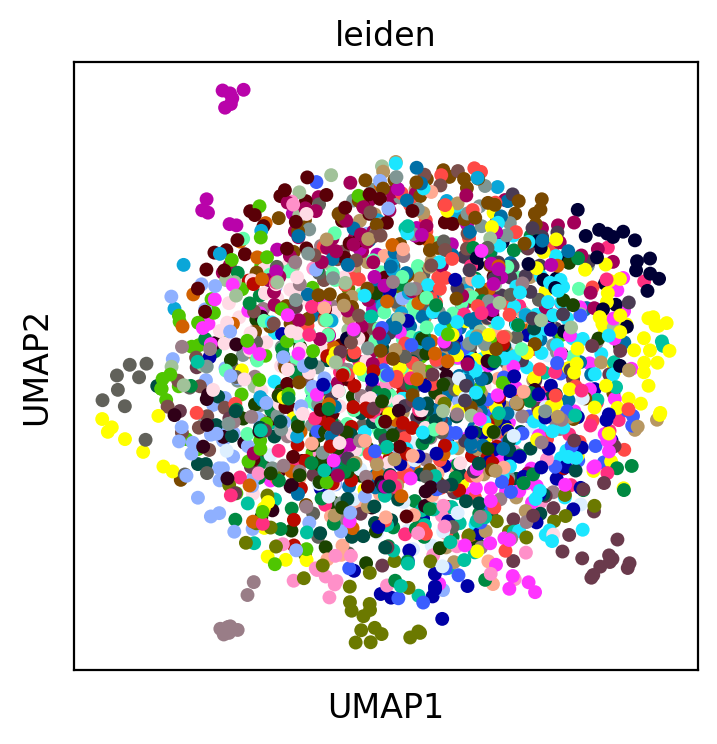

In [14]:
respAnnDat = sc.AnnData(X=unique_guideembeddings)
respAnnDat.obs["targetGene"] = [x.split("_")[0] for x in respAnnDat.obs.index]
#sc.pp.scale(koGuidesAnnDat)
#sc.pp.pca(respAnnDat, svd_solver='arpack')
sc.pp.neighbors(respAnnDat, use_rep='X')
sc.tl.leiden(respAnnDat, resolution=1.5)
sc.tl.umap(respAnnDat)
sc.pl.umap(respAnnDat, 
           color='leiden',
           size=100,  
           legend_fontoutline=3, 
           legend_loc = 'center',
           legend_fontsize=14,
           legend_fontweight='normal')

In [15]:
# respAnnDat.obs["guideName"] = respAnnDat.obs["targetGene"].index
# respAnnDat.obs["isControl"] = '0'
# respAnnDat.obs.loc[respAnnDat.obs["targetGene"] == "CONTROL", "isControl"] = '1'
# respAnnDat.obs.loc[respAnnDat.obs["targetGene"] == "Chd4", "isControl"] = '2'
# respAnnDat.obs.loc[respAnnDat.obs["targetGene"] == "ONE", "isControl"] = '3'
# respAnnDat.obs.loc[respAnnDat.obs["targetGene"] == "NO", "isControl"] = '4'

# sc.set_figure_params(figsize=(8, 8))
# sc.pl.umap(respAnnDat, 
#            color='isControl',
#            legend_fontoutline=3, 
#            legend_fontsize=14,
#            legend_fontweight='normal',
#            size = 100,
#            palette='Paired')

In [16]:
#from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import manhattan_distances
from sklearn.metrics.pairwise import cosine_distances


pairwiseDist = euclidean_distances(unique_guideembeddings, 
                                          unique_guideembeddings)

# il1 = np.tril_indices(myDist.shape[0])
# myDist[il1] = np.nan

pairwiseDist = pd.DataFrame(pairwiseDist)

pairwiseDist.index = unique_guideembeddings.index
pairwiseDist.columns = pairwiseDist.index


pairwiseDistCosine = cosine_distances(unique_guideembeddings, 
                                          unique_guideembeddings)

pairwiseDistCosine = pd.DataFrame(pairwiseDistCosine)

pairwiseDistCosine.index = unique_guideembeddings.index
pairwiseDistCosine.columns = pairwiseDistCosine.index


In [17]:
noTargetGuides = [x.split("_")[0] == 'NO' for x in pairwiseDist.index]
noTargets = list(pairwiseDist.loc[noTargetGuides, noTargetGuides].index)

oneNongeneGuides = [x.split("_")[0] == 'ONE' for x in pairwiseDist.index]
oneNongenes = list(pairwiseDist.loc[oneNongeneGuides, oneNongeneGuides].index)

In [18]:
targetGenes = list(set([x.split("_")[0] for x in pairwiseDist.index]))
targetGenes.sort()
targetGenes = [x for x in targetGenes if x not in ["CONTROL", "NO", "ONE"]]


In [19]:
threshold = 0.92
tmp = pairwiseDist.loc[pairwiseDist.mean(axis=0) > threshold,pairwiseDist.mean(axis=0) > threshold]

selGenes = list(set([x.split("_")[0] for x in tmp.index]))
selGenes = [x for x in selGenes if x not in  ["CONTROL", "NO", "ONE"]]
selGuides = [x + "_1" for x in selGenes] + [x + "_2" for x in selGenes] + [x + "_3" for x in selGenes]
selGuides.sort()

In [20]:
threshold = 0.53
tmp = pairwiseDist.loc[pairwiseDist.mean(axis=0) < threshold,pairwiseDist.mean(axis=0) < threshold]

selGenes2 = list(set([x.split("_")[0] for x in tmp.index]))
selGenes2 = [x for x in selGenes2 if x not in  ["CONTROL", "NO", "ONE"]]
selGuides2 = [x + "_1" for x in selGenes2] + [x + "_2" for x in selGenes2] + [x + "_3" for x in selGenes2]
selGuides2.sort()

<AxesSubplot:>

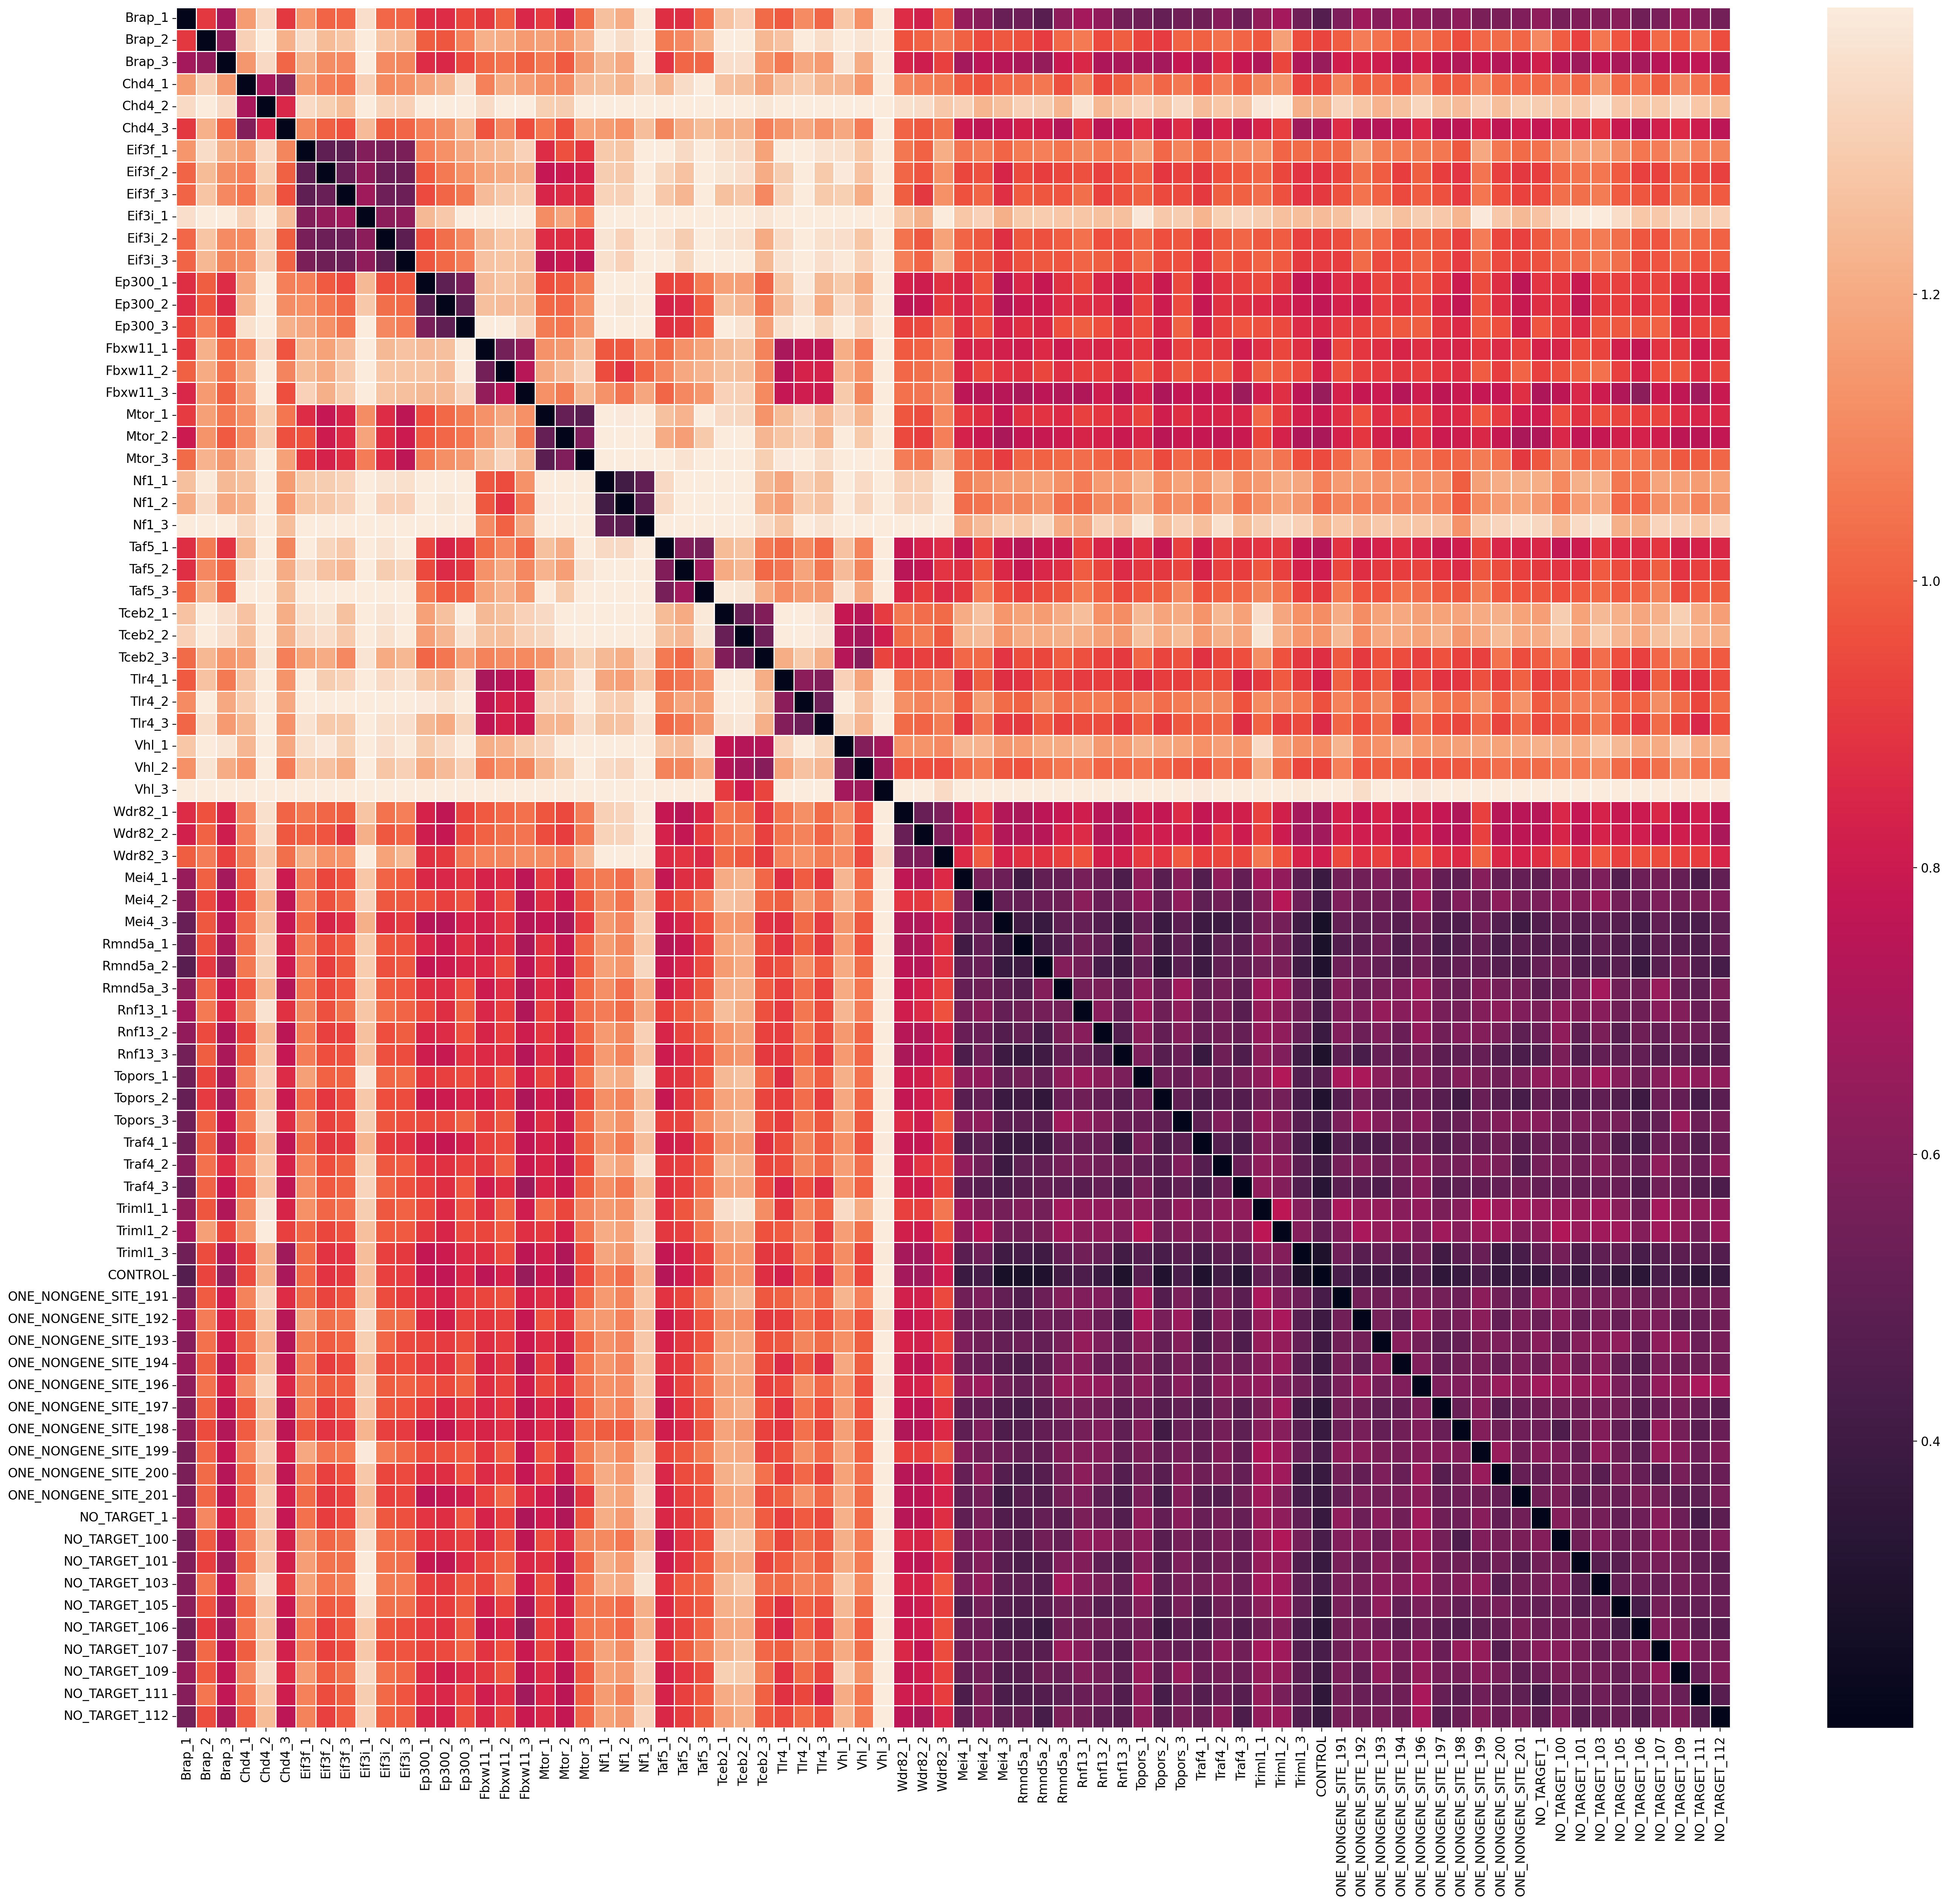

In [21]:
pairwiseDist_Selected = pairwiseDist.loc[selGuides + selGuides2 + ["CONTROL"] + oneNongenes[0:10] + noTargets[0:10],
                                selGuides + selGuides2+ ["CONTROL"] + oneNongenes[0:10] + noTargets[0:10]]

pairwiseDist_SelectedPlot = pairwiseDist_Selected.copy()
pairwiseDist_SelectedPlot[pairwiseDist_SelectedPlot > 1.4] =1.4
pairwiseDist_SelectedPlot[pairwiseDist_SelectedPlot < 0.2] =0.2
fig, ax = plt.subplots(figsize=(33,30))         # Sample figsize in inches
sns.heatmap(pairwiseDist_SelectedPlot,  linewidths=.5, ax=ax)

<AxesSubplot:>

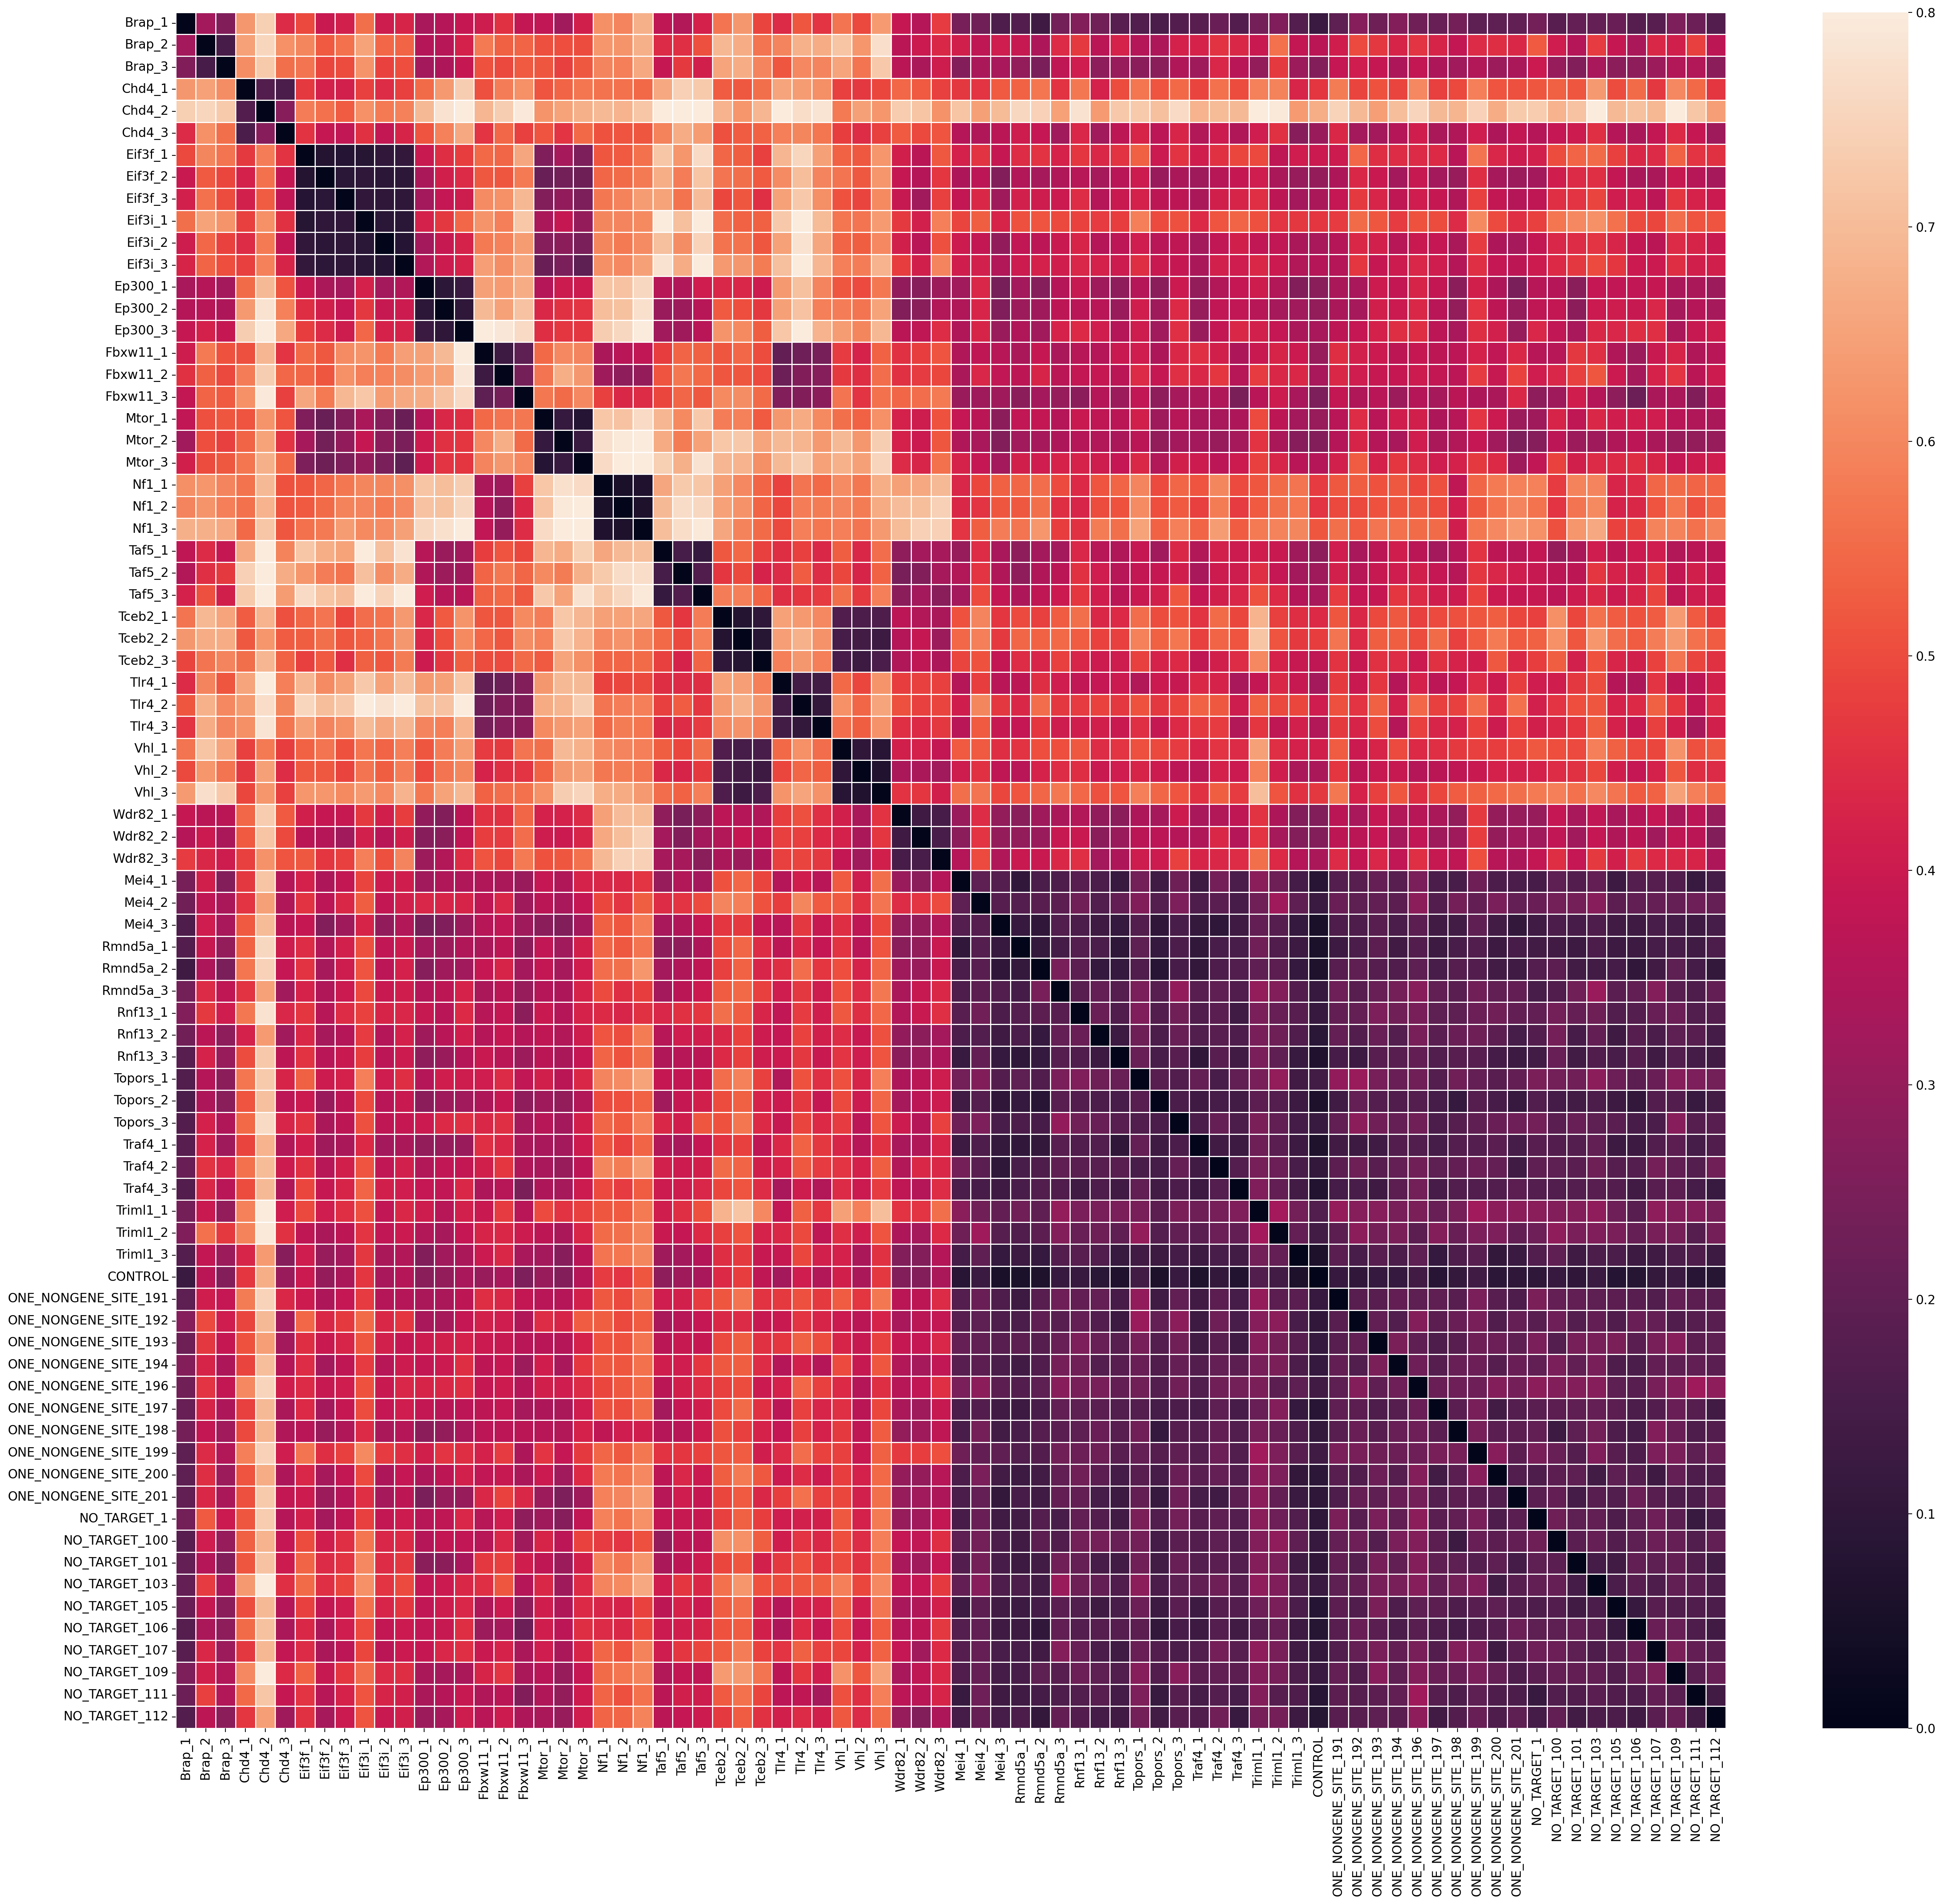

In [22]:
fig, ax = plt.subplots(figsize=(33,30))         # Sample figsize in inches
pairwiseDistCosine_plot = pairwiseDistCosine.loc[pairwiseDist_SelectedPlot.index, pairwiseDist_SelectedPlot.index]
pairwiseDistCosine_plot[pairwiseDistCosine_plot > 0.8] = 0.8
sns.heatmap(pairwiseDistCosine_plot,  linewidths=.5, ax=ax)

In [23]:
allSellGenes = selGenes + selGenes2
allSellGuides = selGuides + selGuides2

In [24]:
allSellGuides

['Brap_1',
 'Brap_2',
 'Brap_3',
 'Chd4_1',
 'Chd4_2',
 'Chd4_3',
 'Eif3f_1',
 'Eif3f_2',
 'Eif3f_3',
 'Eif3i_1',
 'Eif3i_2',
 'Eif3i_3',
 'Ep300_1',
 'Ep300_2',
 'Ep300_3',
 'Fbxw11_1',
 'Fbxw11_2',
 'Fbxw11_3',
 'Mtor_1',
 'Mtor_2',
 'Mtor_3',
 'Nf1_1',
 'Nf1_2',
 'Nf1_3',
 'Taf5_1',
 'Taf5_2',
 'Taf5_3',
 'Tceb2_1',
 'Tceb2_2',
 'Tceb2_3',
 'Tlr4_1',
 'Tlr4_2',
 'Tlr4_3',
 'Vhl_1',
 'Vhl_2',
 'Vhl_3',
 'Wdr82_1',
 'Wdr82_2',
 'Wdr82_3',
 'Mei4_1',
 'Mei4_2',
 'Mei4_3',
 'Rmnd5a_1',
 'Rmnd5a_2',
 'Rmnd5a_3',
 'Rnf13_1',
 'Rnf13_2',
 'Rnf13_3',
 'Topors_1',
 'Topors_2',
 'Topors_3',
 'Traf4_1',
 'Traf4_2',
 'Traf4_3',
 'Triml1_1',
 'Triml1_2',
 'Triml1_3']

In [26]:
import pingouin as pg

In [30]:

k.r

pearson    0.397
Name: r, dtype: float64

In [34]:
k["p-val"] == 0

pearson    True
Name: p-val, dtype: bool

In [76]:
myDat = pd.DataFrame(np.zeros(shape=(len(allSellGuides),len(allSellGuides))), columns=allSellGuides, index=allSellGuides)
testedGuides = []
for i in allSellGuides:
    for j in [x for x in allSellGuides if x not in testedGuides]:
        if i != j:
            # print(i)
            # print(j)
            tmp = pairwiseDistCosine.loc[[i]+[j] +["CONTROL"] + oneNongenes[0:10] + noTargets[0:10],:].T
            # model = GraphicalLassoCV(alphas=5, cv=3)
            # model.fit(tmp)
            #cov_ = pd.DataFrame(model.covariance_)
            #prec_ = pd.DataFrame(model.precision_)
            #prec_.columns = tmp.columns
            #prec_.index = tmp.columns
            k = pg.partial_corr(data=pairwiseDistCosine, x=i, y=j, covar=["CONTROL"] + oneNongenes[0:10] + noTargets[0:10],
                method='pearson').round(3)
            
            if (k["p-val"][0] < 0.05) & (k.r[0] > 0):
                # myDat.loc[i,j] = prec_.loc[i,j]
                # myDat.loc[j,i] = prec_.loc[j,i]
                myDat.loc[i,j] = k.r[0]
                myDat.loc[j,i] = k.r[0]
            
            testedGuides = testedGuides + [i]


In [77]:
myDat

,Brap_1,Brap_2,Brap_3,Chd4_1,Chd4_2,Chd4_3,Eif3f_1,Eif3f_2,Eif3f_3,Eif3i_1,...,Rnf13_3,Topors_1,Topors_2,Topors_3,Traf4_1,Traf4_2,Traf4_3,Triml1_1,Triml1_2,Triml1_3
Brap_1,0.000,0.397,0.369,0.000,0.000,0.000,0.000,0.000,0.128,0.000,...,0.062,0.421,0.000,0.232,0.077,0.000,0.000,0.299,0.000,0.000
Brap_2,0.397,0.000,0.758,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.101,0.285,0.145,0.000,0.000,0.000,0.000,0.095,0.000,0.000
Brap_3,0.369,0.758,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.180,0.200,0.000,0.000,0.170,0.000,0.000,0.278,0.000,0.000
Chd4_1,0.000,0.000,0.000,0.000,0.855,0.810,0.326,0.309,0.283,0.298,...,0.000,0.000,0.117,0.000,0.000,0.000,0.109,0.000,0.118,0.281
Chd4_2,0.000,0.000,0.000,0.855,0.000,0.741,0.444,0.420,0.450,0.379,...,0.000,0.000,0.059,0.000,0.000,0.143,0.000,0.000,0.061,0.284
Chd4_3,0.000,0.000,0.000,0.810,0.741,0.000,0.261,0.232,0.317,0.298,...,0.000,0.000,0.059,0.000,0.000,0.000,0.122,0.000,0.110,0.333
Eif3f_1,0.000,0.000,0.000,0.326,0.444,0.261,0.000,0.902,0.872,0.902,...,0.000,0.000,0.000,0.000,0.271,0.000,0.000,0.000,0.126,0.178
Eif3f_2,0.000,0.000,0.000,0.309,0.420,0.232,0.902,0.000,0.845,0.890,...,0.000,0.000,0.000,0.180,0.371,0.049,0.000,0.000,0.102,0.141
Eif3f_3,0.128,0.000,0.000,0.283,0.450,0.317,0.872,0.845,0.000,0.872,...,0.000,0.000,0.000,0.213,0.408,0.000,0.000,0.000,0.109,0.298
Eif3i_1,0.000,0.000,0.000,0.298,0.379,0.298,0.902,0.890,0.872,0.000,...,0.000,0.000,0.000,0.109,0.389,0.000,0.000,0.072,0.054,0.085


<AxesSubplot:>

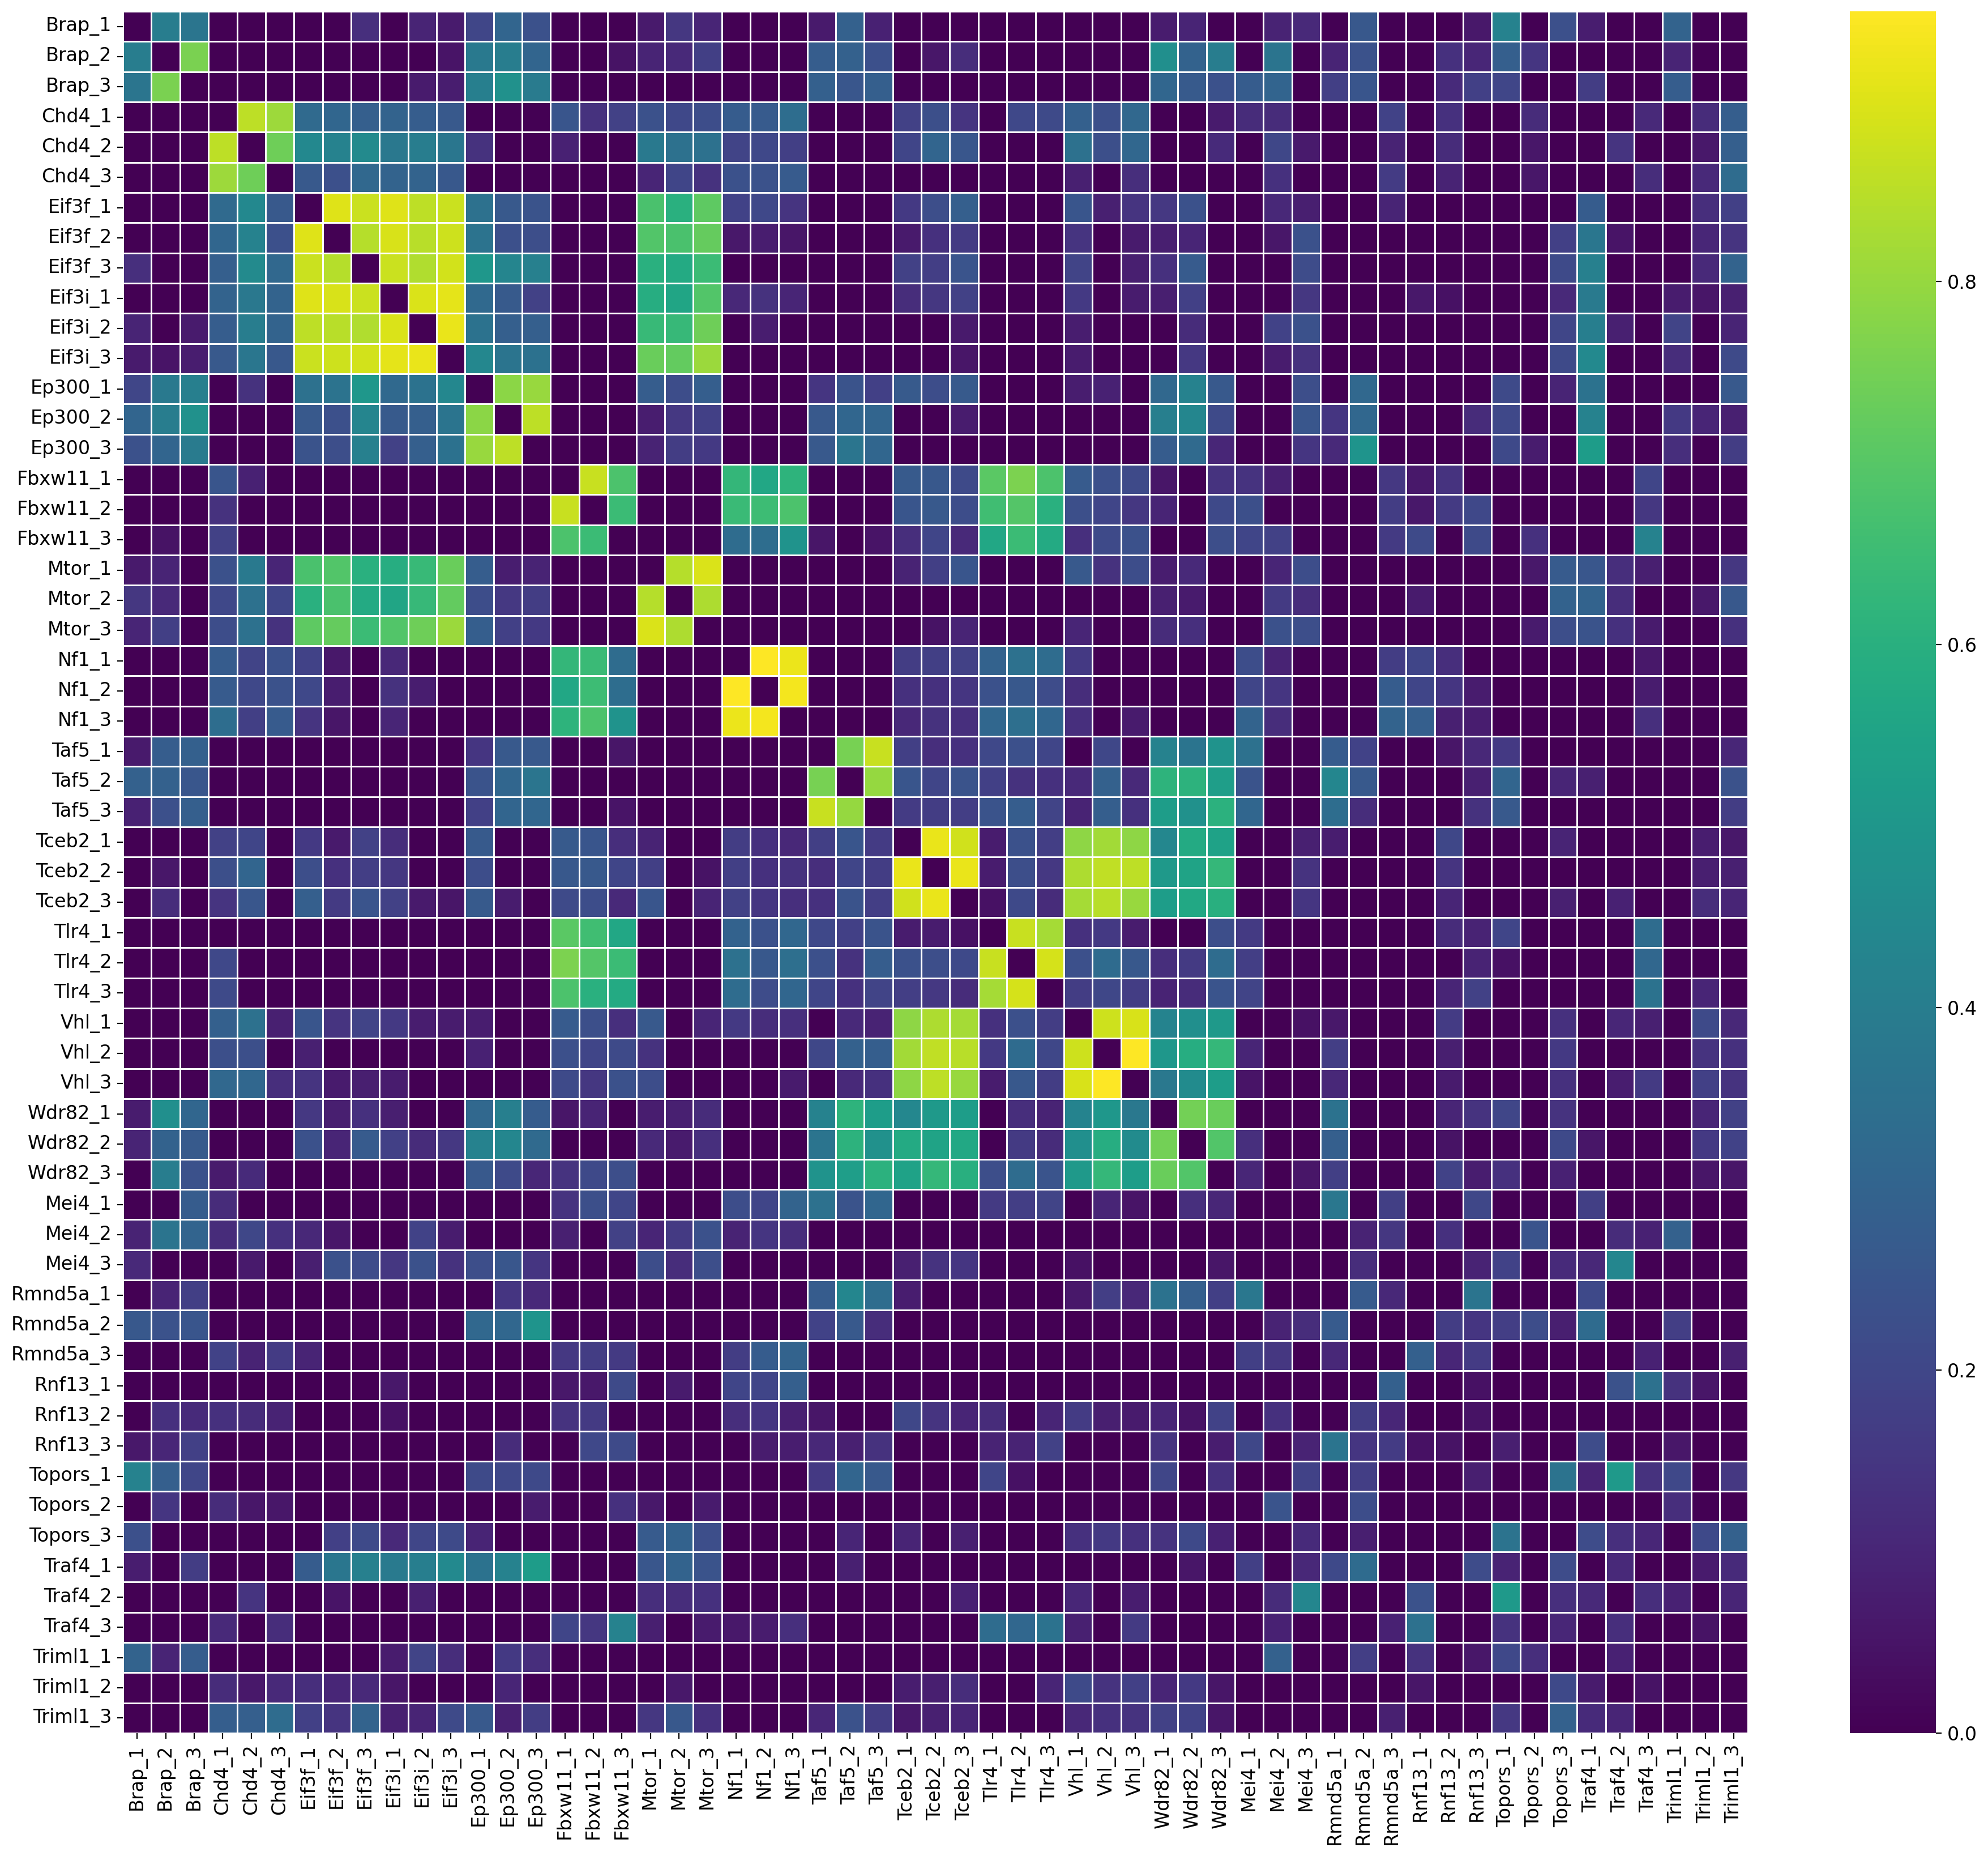

In [78]:
prec_Plot = myDat.copy()

#prec_Plot.values[[np.arange(prec_Plot.shape[0])]*2] = np.nan
#prec_Plot[prec_Plot < 0.5] = 0
fig, ax = plt.subplots(figsize=(23,20))         # Sample figsize in inches
sns.heatmap(prec_Plot,  linewidths=.5, ax=ax, cmap='viridis')

In [41]:
myDist_1Copy = np.array(pairwiseDistCosine)
il1 = np.tril_indices(myDist_1Copy.shape[0])
myDist_1Copy[il1] = np.nan
myDist_1Copy = pd.DataFrame(myDist_1Copy)
myDist_1Copy.index=pairwiseDistCosine.index
myDist_1Copy.columns=pairwiseDistCosine.columns


In [42]:
myDistMelted = pd.melt(myDist_1Copy, id_vars=None, ignore_index=False)
myDistMelted["secondGuide"] = myDistMelted.index
myDistMelted.columns=["FirstGuide", "Distance", "SecondGuide"]
myDistMelted.index = range(0,myDistMelted.shape[0])
myDistMelted = myDistMelted.loc[~myDistMelted["Distance"].isnull(),:]
 

In [43]:
myDistMelted['FirstGene'] = [x.split("_")[0] for x in myDistMelted['FirstGuide'] ]
myDistMelted['SecondGene'] = [x.split("_")[0] for x in myDistMelted['SecondGuide'] ]
myDistMelted = myDistMelted.loc[myDistMelted["FirstGuide"] != myDistMelted["SecondGuide"],:]


In [44]:
myDistMelted

,FirstGuide,Distance,SecondGuide,FirstGene,SecondGene
2093,4921501E09Rik_2,0.172944,4921501E09Rik_1,4921501E09Rik,4921501E09Rik
4186,4921501E09Rik_3,0.184269,4921501E09Rik_1,4921501E09Rik,4921501E09Rik
4187,4921501E09Rik_3,0.189368,4921501E09Rik_2,4921501E09Rik,4921501E09Rik
6279,4930595M18Rik_1,0.152013,4921501E09Rik_1,4930595M18Rik,4921501E09Rik
6280,4930595M18Rik_1,0.148093,4921501E09Rik_2,4930595M18Rik,4921501E09Rik
...,...,...,...,...,...
4380643,CONTROL,0.161633,Zmiz1_2,CONTROL,Zmiz1
4380644,CONTROL,0.133156,Zmiz1_3,CONTROL,Zmiz1
4380645,CONTROL,0.084760,Zpbp2_1,CONTROL,Zpbp2
4380646,CONTROL,0.110000,Zpbp2_2,CONTROL,Zpbp2


In [45]:
myDistMelted["GuideType"] = "Different_gene"
myDistMelted.loc[myDistMelted["FirstGene"] == myDistMelted["SecondGene"],"GuideType"] = "Same_gene"

myDistMelted.loc[myDistMelted["FirstGene"] == "NO","GuideType"] = "NO_TARGET_KO"
myDistMelted.loc[myDistMelted["SecondGene"] == "NO","GuideType"] = "NO_TARGET_KO"

myDistMelted.loc[myDistMelted["FirstGene"] == "ONE","GuideType"] = "NON_GENE_KO"
myDistMelted.loc[myDistMelted["SecondGene"] == "ONE","GuideType"] = "NON_GENE_KO"

myDistMelted.loc[myDistMelted["FirstGene"] == "CONTROL","GuideType"] = "CONTROL_KO"
myDistMelted.loc[myDistMelted["SecondGene"] == "CONTROL","GuideType"] = "CONTROL_KO"


myDistMelted.loc[(myDistMelted["FirstGene"] == "NO") & (myDistMelted["SecondGene"] == "NO"),"GuideType"] = "NO_TARGET_NO_TARGET"
myDistMelted.loc[(myDistMelted["FirstGene"] == "ONE") & (myDistMelted["SecondGene"] == "ONE"),"GuideType"] = "NON_GENE_NON_GENE"
myDistMelted.loc[(myDistMelted["FirstGene"] == "ONE") & (myDistMelted["SecondGene"] == "NO"),"GuideType"] = "NON_GENE_NO_TARGET"
myDistMelted.loc[(myDistMelted["FirstGene"] == "NO") & (myDistMelted["SecondGene"] == "ONE"),"GuideType"] = "NON_GENE_NO_TARGET"
myDistMelted.loc[(myDistMelted["FirstGene"] == "ONE") & (myDistMelted["SecondGene"] == "CONTROL"),"GuideType"] = "NON_GENE_CONTROL"
myDistMelted.loc[(myDistMelted["FirstGene"] == "CONTROL") & (myDistMelted["SecondGene"] == "ONE"),"GuideType"] = "NON_GENE_CONTROL"
myDistMelted.loc[(myDistMelted["FirstGene"] == "NO") & (myDistMelted["SecondGene"] == "CONTROL"),"GuideType"] = "NON_TARGET_CONTROL"
myDistMelted.loc[(myDistMelted["FirstGene"] == "CONTROL") & (myDistMelted["SecondGene"] == "NO"),"GuideType"] = "NON_TARGET_CONTROL"

  


In [46]:
myDistMelted

,FirstGuide,Distance,SecondGuide,FirstGene,SecondGene,GuideType
2093,4921501E09Rik_2,0.172944,4921501E09Rik_1,4921501E09Rik,4921501E09Rik,Same_gene
4186,4921501E09Rik_3,0.184269,4921501E09Rik_1,4921501E09Rik,4921501E09Rik,Same_gene
4187,4921501E09Rik_3,0.189368,4921501E09Rik_2,4921501E09Rik,4921501E09Rik,Same_gene
6279,4930595M18Rik_1,0.152013,4921501E09Rik_1,4930595M18Rik,4921501E09Rik,Different_gene
6280,4930595M18Rik_1,0.148093,4921501E09Rik_2,4930595M18Rik,4921501E09Rik,Different_gene
...,...,...,...,...,...,...
4380643,CONTROL,0.161633,Zmiz1_2,CONTROL,Zmiz1,CONTROL_KO
4380644,CONTROL,0.133156,Zmiz1_3,CONTROL,Zmiz1,CONTROL_KO
4380645,CONTROL,0.084760,Zpbp2_1,CONTROL,Zpbp2,CONTROL_KO
4380646,CONTROL,0.110000,Zpbp2_2,CONTROL,Zpbp2,CONTROL_KO


Text(0.5, 1.0, 'Distribution of cosine distances between guides in the guide embedding space')

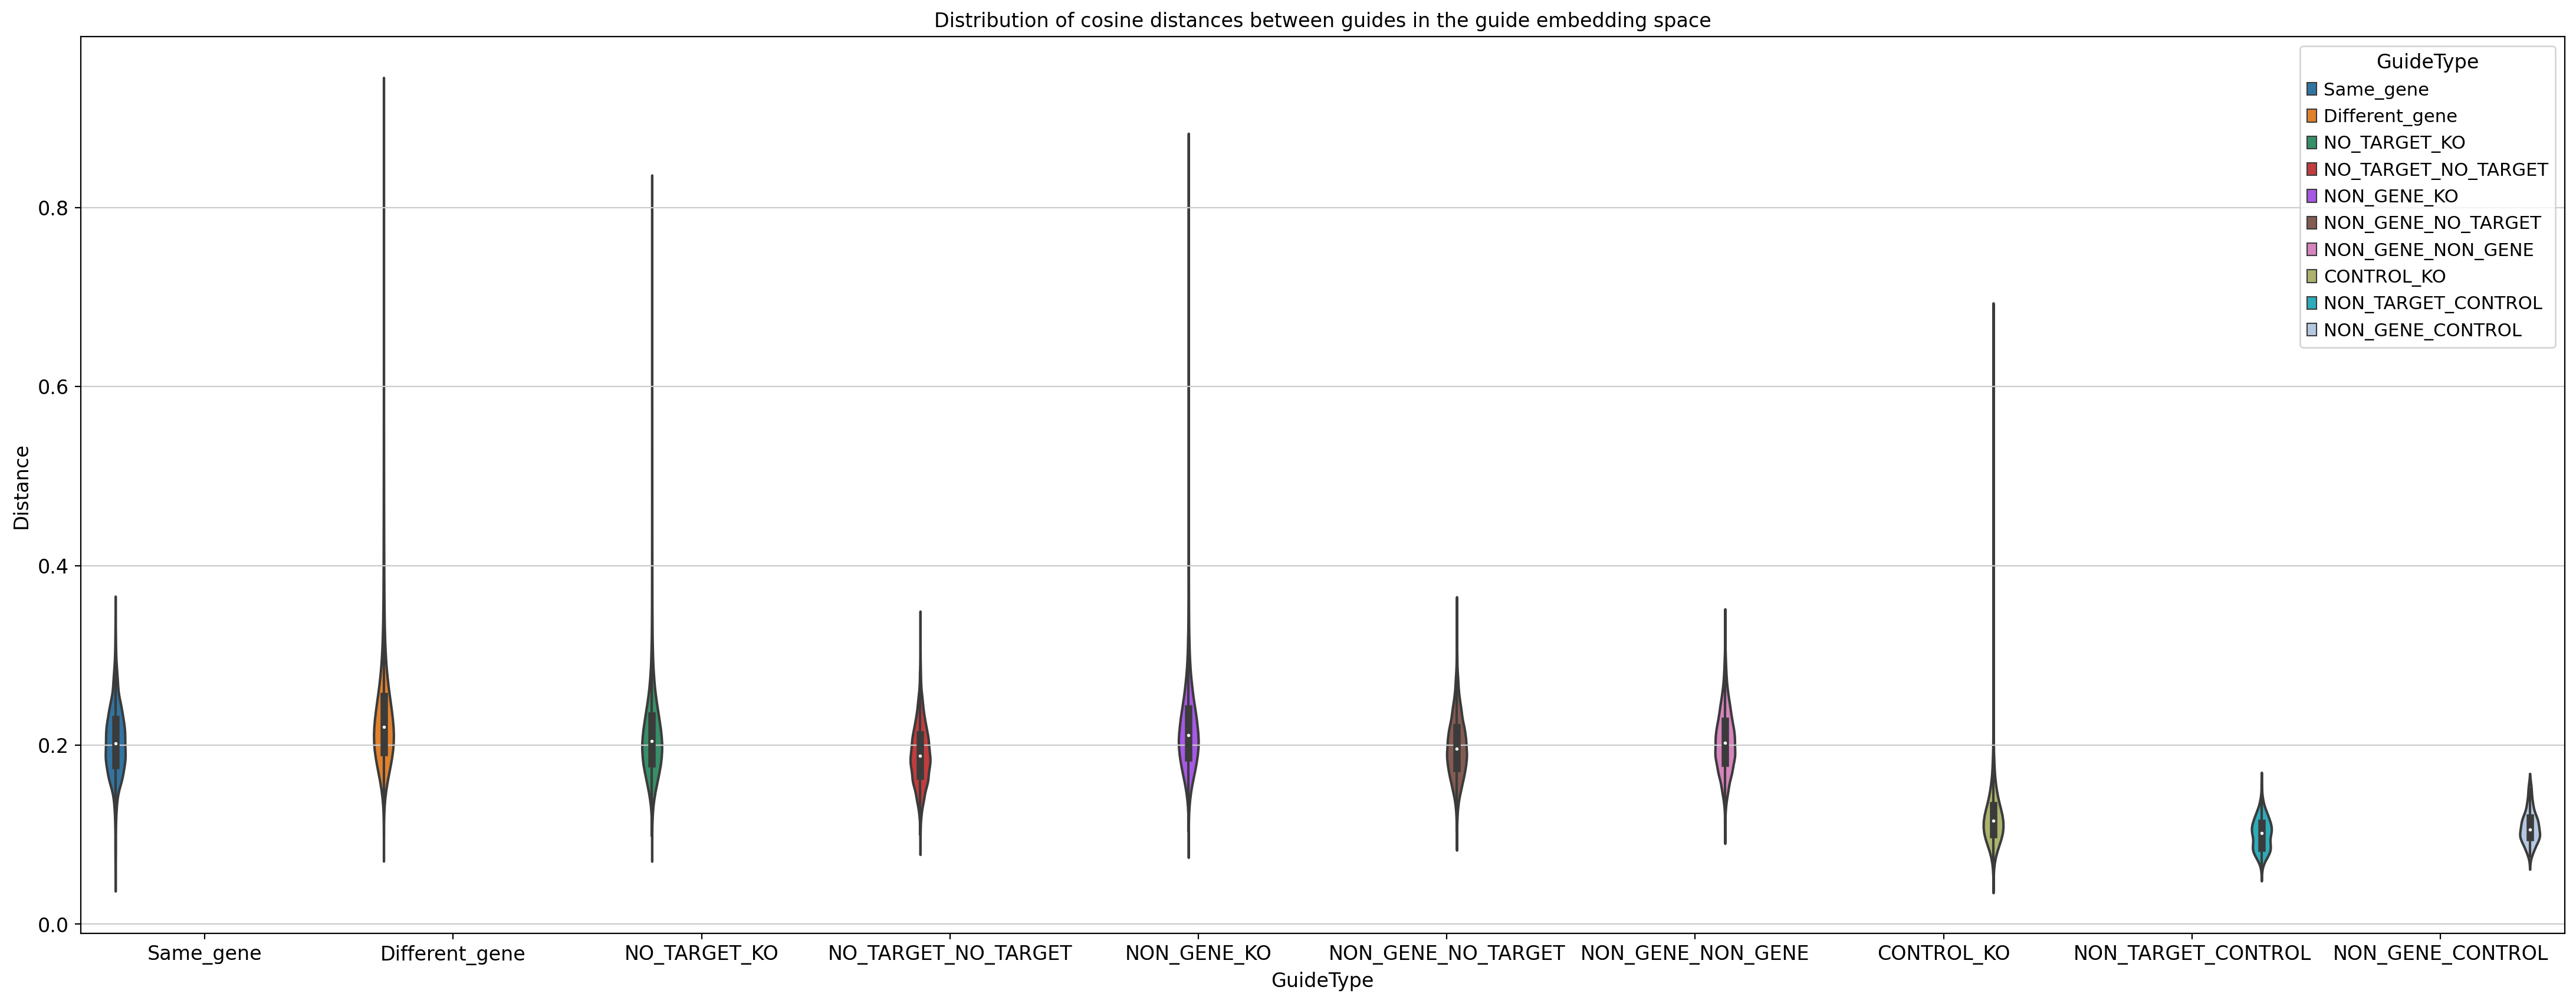

In [47]:
fig, ax = plt.subplots(figsize=(27, 10))
# sns.histplot(data=myDistMelted, 
#              x='Distance', 
#              hue='GuideType', 
#              binwidth=0.03,
#              kde=True)
sns.violinplot(data=myDistMelted, x="GuideType", y="Distance", hue="GuideType")
ax.set_title('Distribution of cosine distances between guides in the guide embedding space')

In [48]:
genesHighVar = myDistMelted.loc[(myDistMelted.GuideType == "Same_gene") & (myDistMelted.Distance > 0.30),"FirstGene"]

In [49]:
genesHighVar

104698        Arih1
224057          Bid
265937         Brap
850163       Fbxo11
925547        Fbxo4
959050        Fbxw7
996742        Foxo3
1028153     Gm10696
1580969       Klhl6
1712891        Ltbr
1781993      March5
2246860       Nsmaf
2858308    Rnf113a2
3002795      Rnf183
3216383       Socs5
3241510        Ssr3
3279203       Syvn1
3515825      Trim25
3536764       Trim2
3723131      Triml1
3781763     Ube2d2a
4202657      Zbtb10
4372271       Zmiz1
Name: FirstGene, dtype: object

In [50]:
selGuidesHighVar = [x + "_1" for x in genesHighVar] + [x + "_2" for x in genesHighVar] + [x + "_3" for x in genesHighVar]
selGuidesHighVar.sort()
len(selGuidesHighVar)

69

In [51]:
pairwiseDist_Selected = pairwiseDistCosine.loc[selGuidesHighVar , selGuidesHighVar]

pairwiseDist_SelectedPlot = pairwiseDist_Selected.copy()
myInt = len(selGuidesHighVar)
for i in range(0,myInt,3):

    if (i-3 >= 0) :
        #pairwiseDist_SelectedPlot.iloc[0:i-1,:]=0
        pairwiseDist_SelectedPlot.iloc[i,0:i]=np.nan
        pairwiseDist_SelectedPlot.iloc[i+1,0:i]=np.nan
        pairwiseDist_SelectedPlot.iloc[i+2,0:i]=np.nan
       
        
    if (i+3 < myInt):
        k = i+3
        pairwiseDist_SelectedPlot.iloc[i,k:myInt]=np.nan
        pairwiseDist_SelectedPlot.iloc[i+1,k:myInt]=np.nan
        pairwiseDist_SelectedPlot.iloc[i+2,k:myInt]=np.nan
        
# pairwiseDist_SelectedPlot[pairwiseDist_SelectedPlot > 0.5] =0.5
# #pairwiseDist_SelectedPlot[pairwiseDist_SelectedPlot < 0.2] =0.2


In [52]:
deneme = pd.concat([pairwiseDist_SelectedPlot, pairwiseDistCosine.loc[selGuidesHighVar , oneNongenes[0:10] + noTargets[0:10]]], axis=1) 

<AxesSubplot:>

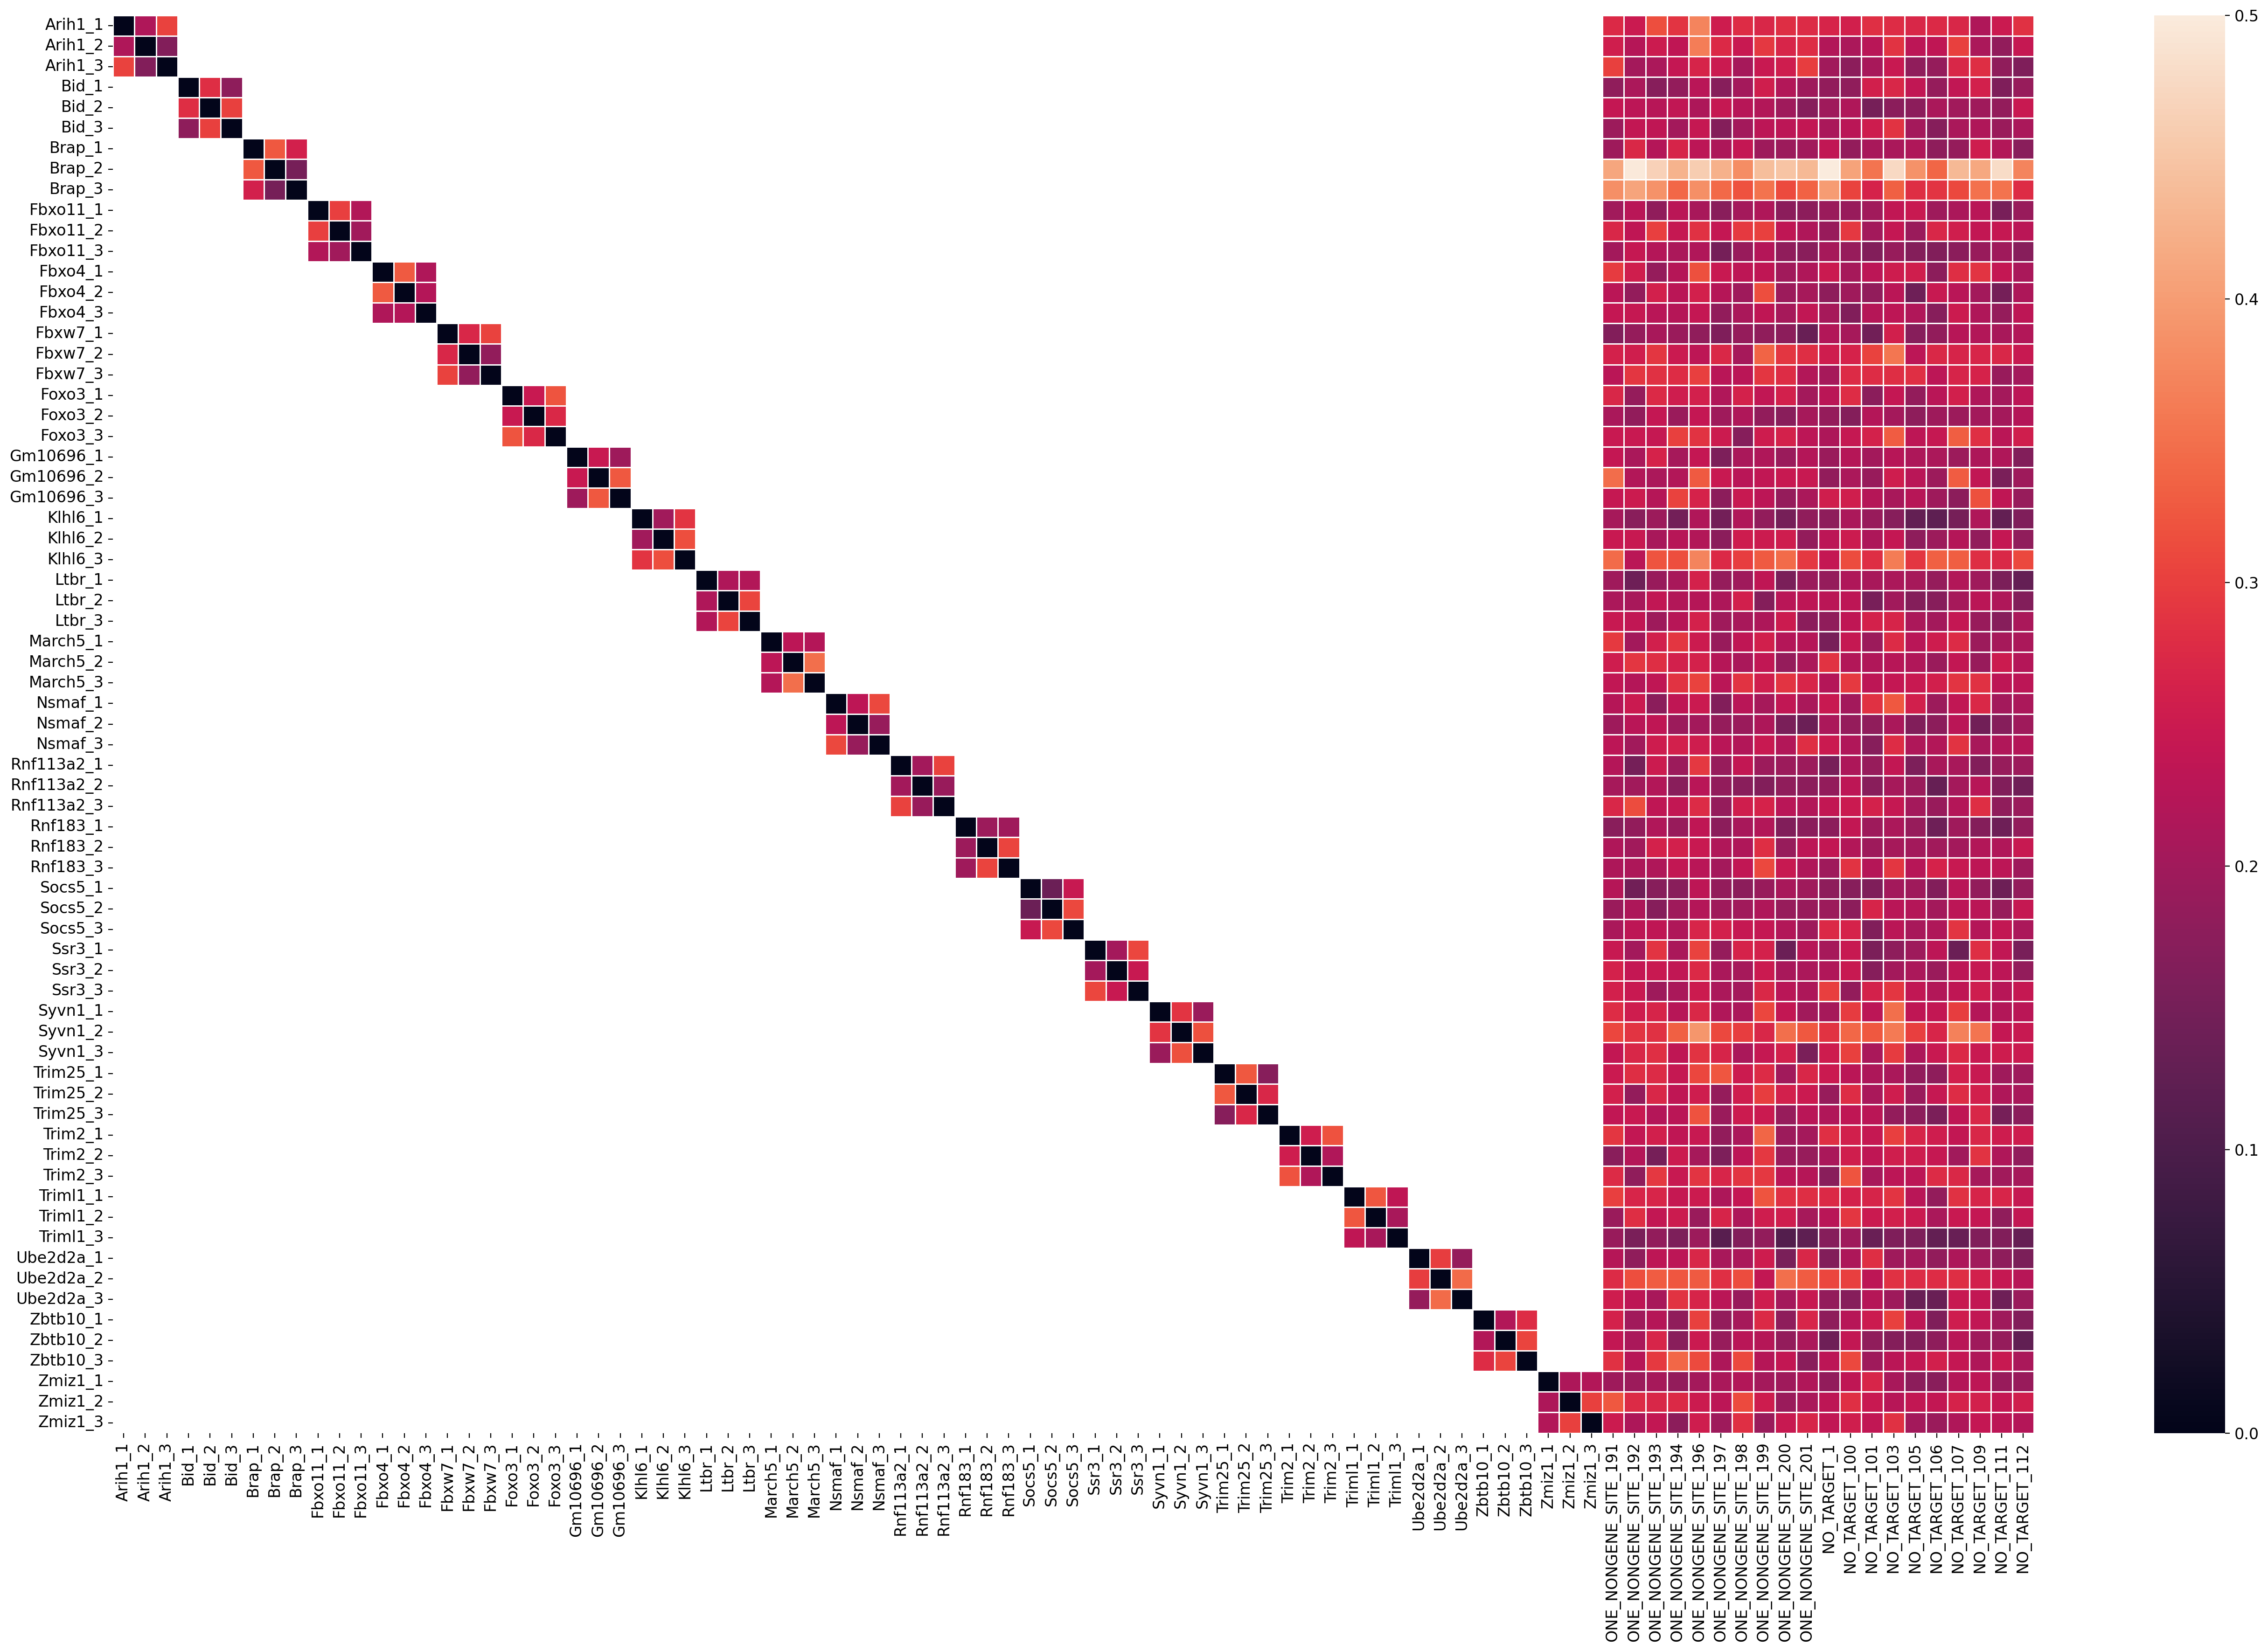

In [53]:
fig, ax = plt.subplots(figsize=(33,20))         # Sample figsize in inches
deneme[deneme > 0.5] = 0.5
sns.heatmap(deneme,  linewidths=.5, ax=ax)

In [82]:
myDat2 = pd.DataFrame(np.zeros(shape=(len(selGuidesHighVar),len(selGuidesHighVar))), columns=selGuidesHighVar, index=selGuidesHighVar)
testedGuides = []
for x in genesHighVar:
    for i in [x + "_1", x + "_2", x + "_3"]:
        for j in [x + "_2", x + "_3"]:
            if i != j:
                # print(i)
                # print(j)
                tmp = pairwiseDistCosine.loc[[i]+[j] +["CONTROL"] + oneNongenes[0:10] + noTargets[0:10],:].T
                model = GraphicalLassoCV(alphas=5, cv=3)
                model.fit(tmp)
                cov_ = pd.DataFrame(model.covariance_)
                prec_ = pd.DataFrame(model.precision_)
                prec_.columns = tmp.columns
                prec_.index = tmp.columns

                myDat2.loc[i,j] = prec_.loc[i,j]
                myDat2.loc[j,i] = prec_.loc[j,i]

#                 k = pg.partial_corr(data=pairwiseDistCosine, x=i, y=j, covar=["CONTROL"] + oneNongenes[0:10] + noTargets[0:10],
#                 method='pearson').round(3)
            
#                 if (k["p-val"][0] < 0.05) & (k.r[0] > 0):
#                     myDat2.loc[i,j] = k.r[0]
#                     myDat2.loc[j,i] = k.r[0]

                testedGuides = testedGuides + [i]


/home/eraslab1/miniconda3/lib/python3.8/site-packages/sklearn/covariance/_graph_lasso.py:291: RuntimeWarning: invalid value encountered in multiply
  precision_[indices != idx, idx] = -precision_[idx, idx] * coefs
/home/eraslab1/miniconda3/lib/python3.8/site-packages/sklearn/covariance/_graph_lasso.py:292: RuntimeWarning: invalid value encountered in multiply
  precision_[idx, indices != idx] = -precision_[idx, idx] * coefs
/home/eraslab1/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:232: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/home/eraslab1/miniconda3/lib/python3.8/site-packages/sklearn/covariance/_graph_lasso.py:262: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.304257806819807e-08, tolerance: 7.152732393634843e-09
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
/home/eraslab1/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:232: R

In [83]:
prec_Plot = myDat2.copy()

for i in range(0,myInt,3):

    if (i-3 >= 0) :
        prec_Plot.iloc[i,0:i]=np.nan
        prec_Plot.iloc[i+1,0:i]=np.nan
        prec_Plot.iloc[i+2,0:i]=np.nan

    if (i+3 < myInt):
        k = i+3
        prec_Plot.iloc[i,k:myInt]=np.nan
        prec_Plot.iloc[i+1,k:myInt]=np.nan
        prec_Plot.iloc[i+2,k:myInt]=np.nan
        
#prec_Plot.values[[np.arange(prec_Plot.shape[0])]*2] = np.nan
#prec_Plot[prec_Plot > 0] = 0.5
prec_Plot[prec_Plot < 0] = 0.5


<AxesSubplot:>

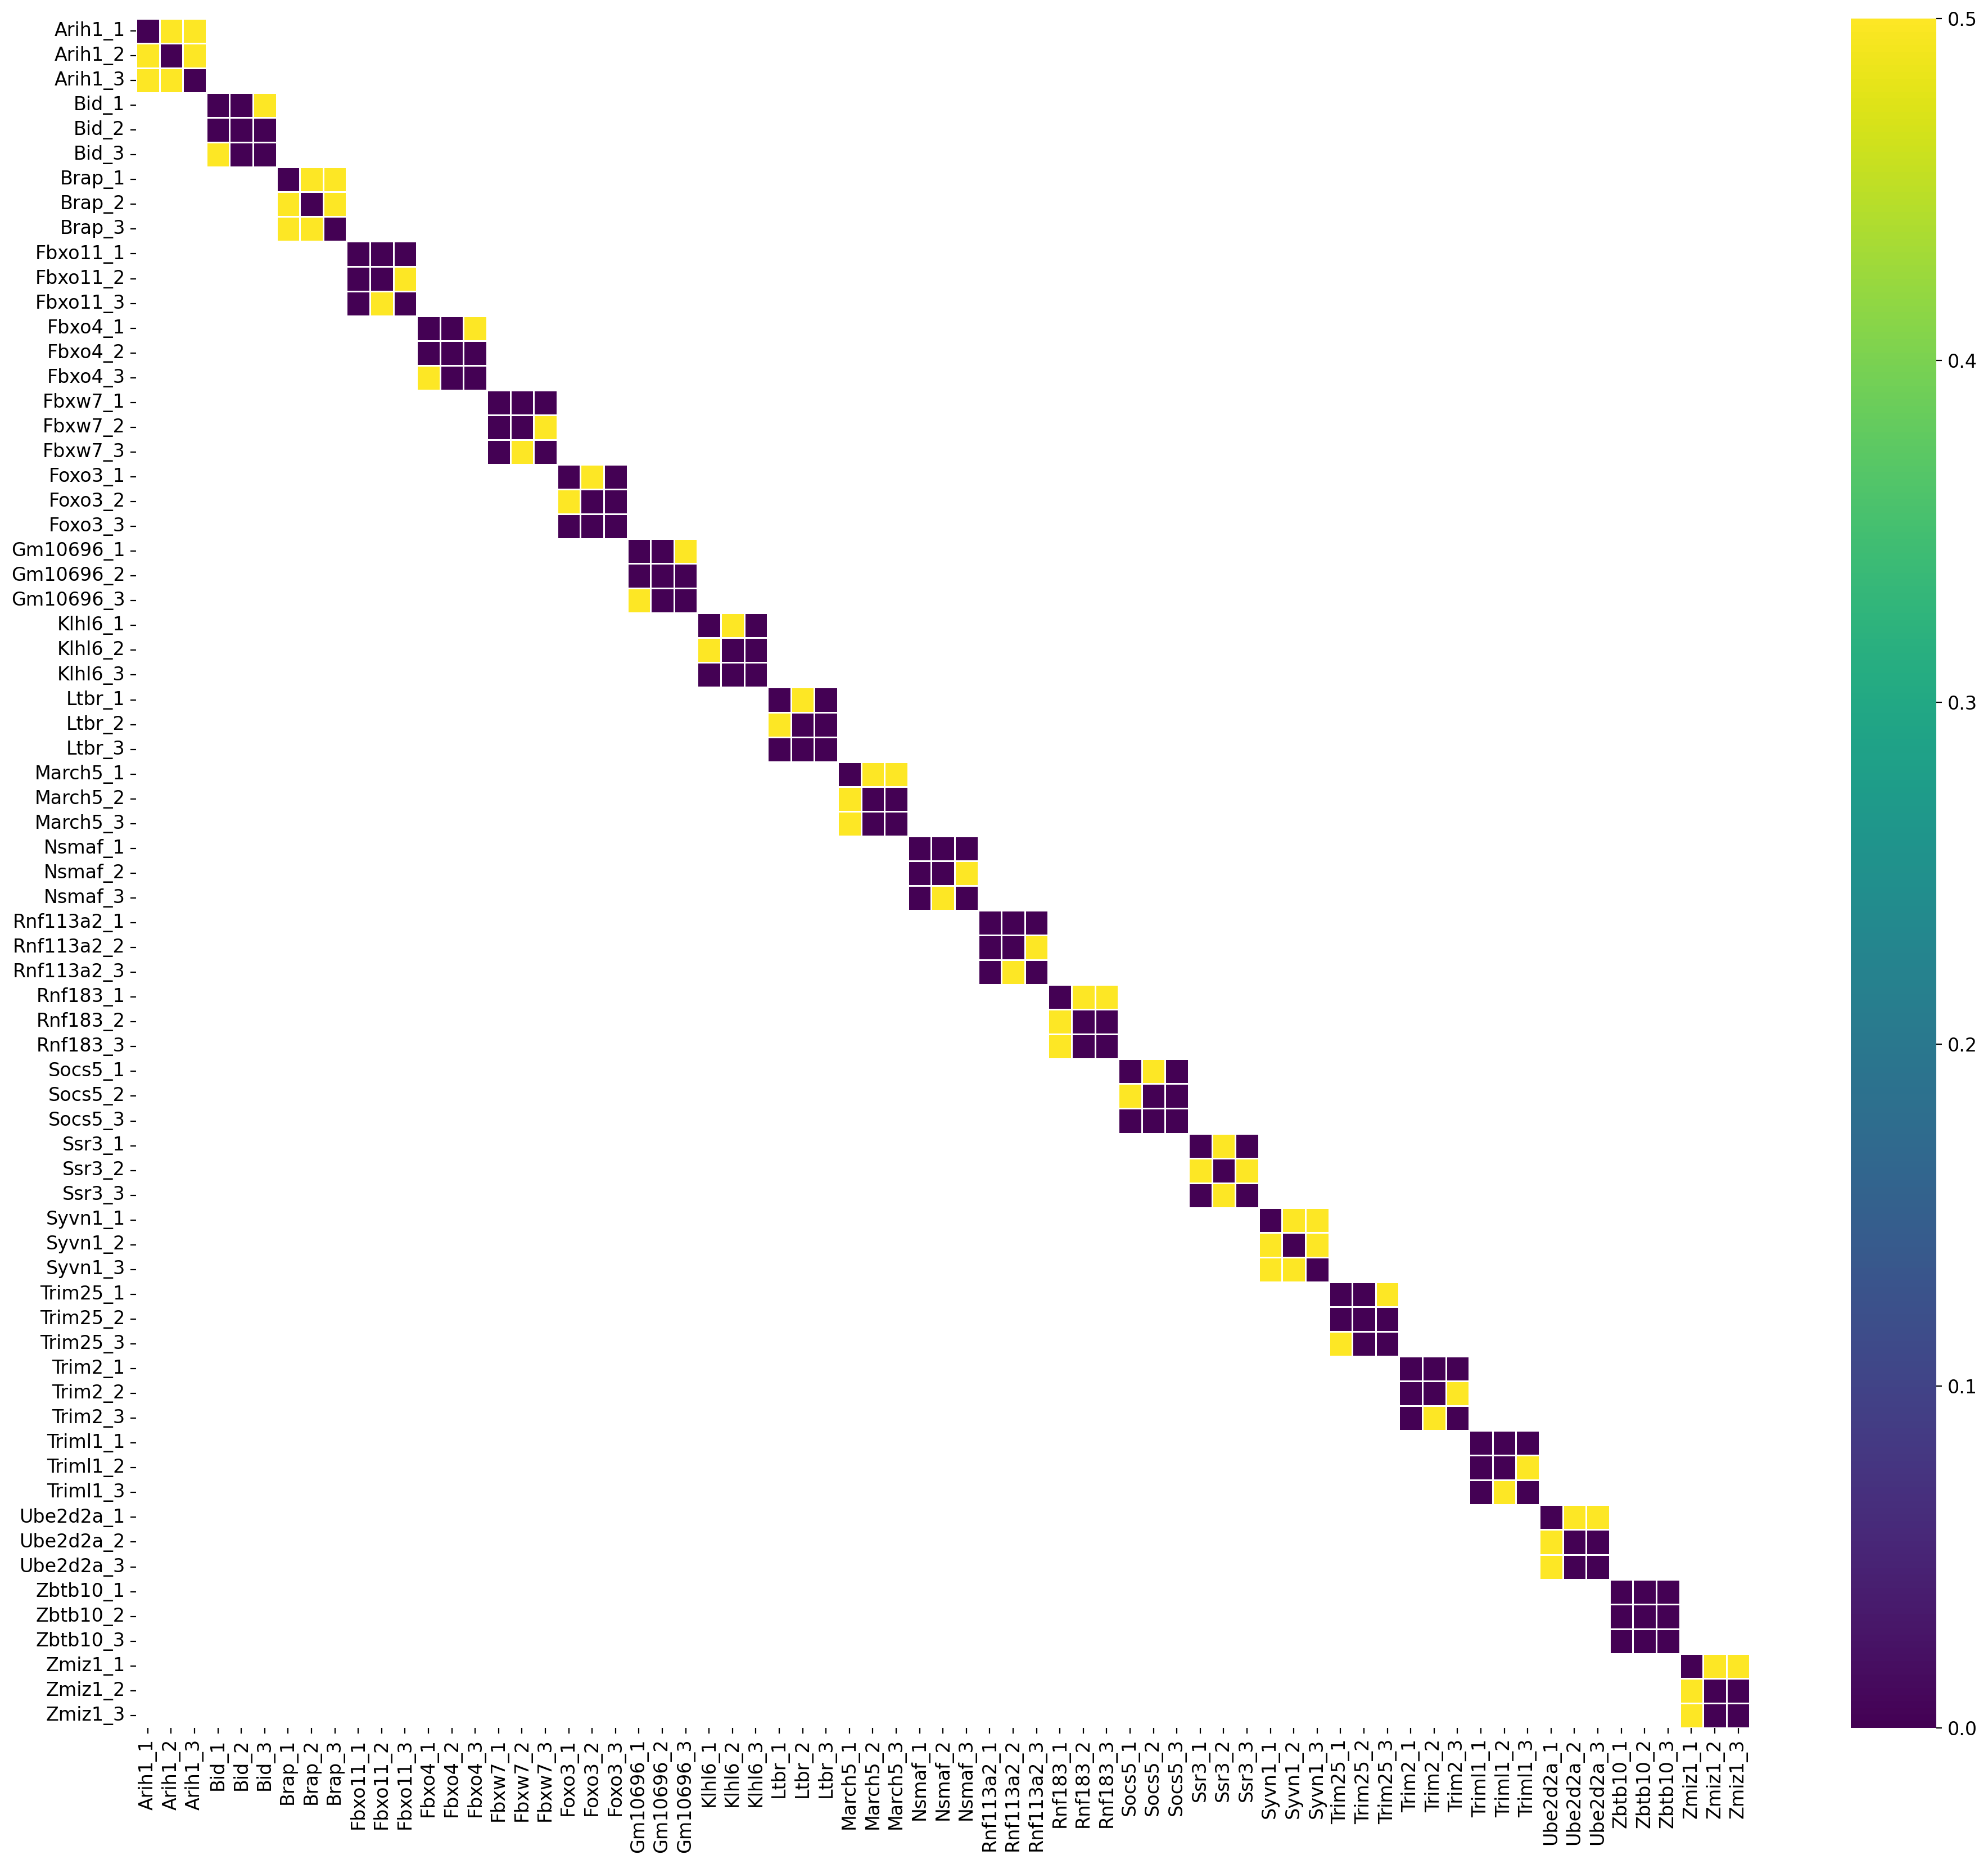

In [84]:
fig, ax = plt.subplots(figsize=(23,20))         # Sample figsize in inches
sns.heatmap(prec_Plot,  linewidths=.5, ax=ax, cmap="viridis")

In [ ]:
# fig, ax = plt.subplots(figsize=(40,40))         # Sample figsize in inches
# sns.heatmap(myDist_1.iloc[1700:1867,1700:1867],  linewidths=.5, ax=ax)

In [ ]:
threshold = 1.1
#myDist_1_selected = myDist_1.loc[myDist_1.mean(axis=0) > threshold,myDist_1.mean(axis=0) > threshold]
myDist_1_selected = myDist_1.iloc[1700:1867,1700:1867]
random.seed(4)
# myDist_1_selected = random.sample(set(myDist_1.index), round(len(myDist_1.index)*0.05))
# myDist_1_selected = myDist_1.loc[myDist_1_selected, myDist_1_selected]

In [ ]:
myDist_1Selected = myDist_1.loc[selGuides + ["CONTROL"],selGuides + ["CONTROL"]]

myDist_1SelectedPlot = myDist_1Selected.copy()
myDist_1SelectedPlot[myDist_1SelectedPlot > 1.4] =1.4
myDist_1SelectedPlot[myDist_1SelectedPlot < 0.2] =0.2
fig, ax = plt.subplots(figsize=(23,20))         # Sample figsize in inches
sns.heatmap(myDist_1SelectedPlot,  linewidths=.5, ax=ax)

In [ ]:
myDist_1Selected_plot = getDistDistr(myDist_1Selected)
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=myDist_1Selected_plot, 
             x='EuclidianDistance', 
             hue='GuideType', 
             binwidth=0.03,
             kde=True)
#sns.violinplot(data=myDist_1Selected_plot, x="GuideType", y="EuclidianDistance", hue="GuideType")
ax.set_title('Distribution of euclidian distances between guides in the guide embedding space')

In [ ]:



model = GraphicalLassoCV(alphas=5)
model.fit(myDist_1Selected)
cov_ = pd.DataFrame(model.covariance_)
prec_ = pd.DataFrame(model.precision_)

cov_.index=myDist_1Selected.index
cov_.columns=myDist_1Selected.columns

prec_.index=myDist_1Selected.index
prec_.columns=myDist_1Selected.columns


In [ ]:
precDist_plot = getDistDistr(prec_)
fig, ax = plt.subplots(figsize=(4.5, 4))
# sns.histplot(data=precDist_plot, 
#              x='EuclidianDistance', 
#              hue='GuideType', 
#              binwidth=0.03,
#              kde=True)
sns.violinplot(data=precDist_plot, x="GuideType", y="EuclidianDistance", hue="GuideType")
ax.set_title('Values of precision matrix')
ax.legend([],[], frameon=False)

In [ ]:
cov_plot = getDistDistr(cov_)
fig, ax = plt.subplots(figsize=(4.5, 4))
# sns.histplot(data=cov_plot, 
#              x='EuclidianDistance', 
#              hue='GuideType', 
#              binwidth=0.0003,
#              kde=True)
sns.violinplot(data=cov_plot, x="GuideType", y="EuclidianDistance", hue="GuideType")
ax.set_title('Distribution of euclidian distances between guides in the guide embedding space')
ax.legend([],[], frameon=False)

In [ ]:
prec_Plot = prec_.copy()

prec_Plot.values[[np.arange(prec_Plot.shape[0])]*2] = np.nan
prec_Plot[prec_Plot>0] = 0
fig, ax = plt.subplots(figsize=(23,20))         # Sample figsize in inches
sns.heatmap(prec_Plot,  linewidths=.5, ax=ax)

In [ ]:
cov_Plot = cov_.copy()

cov_Plot[cov_Plot>0.06] = 0.06
fig, ax = plt.subplots(figsize=(40,40))         # Sample figsize in inches
sns.heatmap(cov_Plot,  linewidths=.5, ax=ax)

In [ ]:
myDist = pd.DataFrame(np.corrcoef(myDist_1Selected))
myDist.index = myDist_1Selected.index
myDist.columns = myDist_1Selected.index


In [ ]:
myDist

In [ ]:
myDist_plot = getDistDistr(myDist)
fig, ax = plt.subplots(figsize=(10, 7))
sns.histplot(data=myDist_plot, 
             x='EuclidianDistance', 
             hue='GuideType', 
             binwidth=0.03,
             kde=True)
ax.set_title('Distribution of euclidian distances between guides in the guide embedding space')

In [ ]:
myDistPlot = myDist.copy()
myDistPlot[myDistPlot>0.8] = 0.8
fig, ax = plt.subplots(figsize=(40,40))         # Sample figsize in inches
sns.heatmap(myDistPlot,  linewidths=.5, ax=ax)

In [ ]:
myDist_1Selected.info()

In [ ]:
myDistMeltedSelected.loc[(myDistMeltedSelected["FirstGene"] == "Brap") | (myDistMeltedSelected["SecondGene"] == "Brap"),:]

In [ ]:
myDistMeltedSelected["GuideType"].value_counts()

In [ ]:
from matplotlib import pyplot
pyplot.scatter(unique_guideembeddings.loc["Zbtb34_1",:], unique_guideembeddings.loc["Zbtb34_2",:])
pyplot.show()

In [ ]:
from matplotlib import pyplot
pyplot.scatter(unique_guideembeddings.loc["Zbtb34_1",:], unique_guideembeddings.loc["Zbtb34_3",:])
pyplot.show()

In [ ]:
from matplotlib import pyplot
pyplot.scatter(unique_guideembeddings.loc["Zbtb34_1",:], unique_guideembeddings.loc["CONTROL",:])
pyplot.show()

In [ ]:
from matplotlib import pyplot
pyplot.scatter(unique_guideembeddings.loc["Zbtb34_1",:], unique_guideembeddings.loc["Zmiz1_1",:])
pyplot.show()

In [ ]:
fig, ax = plt.subplots(figsize=(40,40))         # Sample figsize in inches
sns.heatmap(myDist.iloc[1300:1867,1300:1867],  linewidths=.5, ax=ax)

In [ ]:
fig, ax = plt.subplots(figsize=(40,40))         # Sample figsize in inches
sns.heatmap(myDist.iloc[1300:1867,1300:1867],  linewidths=.5, ax=ax)

In [ ]:
corr.iloc[1800:1867,1800:1867]